In [148]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [149]:
density = np.array([0.697, 0.774, 0.634, 0.608, 0.556, 0.403, 0.481, 0.437, 0.666, 0.243, 0.245, 0.343, 0.639, 0.657, 0.360, 0.593, 0.719]).reshape(-1, 1)
sugar_rate = np.array([0.460, 0.376, 0.264, 0.318, 0.215, 0.237, 0.149, 0.211, 0.091, 0.267, 0.057, 0.099, 0.161, 0.198, 0.370, 0.042, 0.103]).reshape(-1, 1)
x = np.hstack((density, sugar_rate))
y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]).reshape(-1, 1)

In [150]:
import torch.utils.data as Data

x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)  
batch_size = 5  
dataset = Data.TensorDataset(x_tensor, y_tensor)
data_iter = Data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [151]:
for X, y in data_iter:
 print(X, '\n', y)
 break

tensor([[0.6660, 0.0910],
        [0.6080, 0.3180],
        [0.2430, 0.2670],
        [0.7740, 0.3760],
        [0.3600, 0.3700]]) 
 tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


In [152]:
def logreg(X, w, b):  
    return 1/(1+torch.exp(-(torch.mm(X, w) + b)))

In [153]:
def crossentropy_loss(y_hat, y): 
    return -torch.mean(y*torch.log(y_hat + 1e-8) + (1-y)*torch.log(1-y_hat + 1e-8))  
#pdf中给的函数使用后最终结果中分割线分割两类的效果太差，这是我在网上搜到的交叉熵损失函数

In [154]:
num_inputs = 2
w = torch.tensor(np.random.normal(0, 0.01, (num_inputs, 1)), dtype=torch.float32)
b = torch.zeros(1, dtype=torch.float32)

In [155]:
def sgd(params, lr, batch_size):  
    for param in params:
     param.data -= lr * param.grad / batch_size

In [156]:
w.requires_grad_(requires_grad=True)
b.requires_grad_(requires_grad=True) 
lr = 0.2 
num_epochs = 1000 
net = logreg 
loss = crossentropy_loss
for epoch in range(num_epochs):  
 for X, y in data_iter:
  l = loss(net(X, w, b), y).sum()  
  l.backward()  
  sgd([w, b], lr, batch_size) 
  w.grad.data.zero_()
  b.grad.data.zero_()
 train_l = loss(net(x_tensor, w, b), y_tensor)
 print('epoch %d, loss %f' % (epoch + 1, train_l.mean().item()))

epoch 1, loss 0.693416
epoch 2, loss 0.693214
epoch 3, loss 0.693252
epoch 4, loss 0.693318
epoch 5, loss 0.693407
epoch 6, loss 0.693098
epoch 7, loss 0.693234
epoch 8, loss 0.692939
epoch 9, loss 0.692647
epoch 10, loss 0.692790
epoch 11, loss 0.692473
epoch 12, loss 0.692166
epoch 13, loss 0.691909
epoch 14, loss 0.691652
epoch 15, loss 0.691382
epoch 16, loss 0.691496
epoch 17, loss 0.691602
epoch 18, loss 0.691295
epoch 19, loss 0.690609
epoch 20, loss 0.690360
epoch 21, loss 0.689816
epoch 22, loss 0.689645
epoch 23, loss 0.689394
epoch 24, loss 0.689237
epoch 25, loss 0.689234
epoch 26, loss 0.689013
epoch 27, loss 0.688802
epoch 28, loss 0.688551
epoch 29, loss 0.688318
epoch 30, loss 0.687881
epoch 31, loss 0.687675
epoch 32, loss 0.687503
epoch 33, loss 0.687262
epoch 34, loss 0.687026
epoch 35, loss 0.686786
epoch 36, loss 0.686594
epoch 37, loss 0.686379
epoch 38, loss 0.686420
epoch 39, loss 0.686474
epoch 40, loss 0.686002
epoch 41, loss 0.685663
epoch 42, loss 0.685640
e

In [157]:
from IPython import display
from torch.utils.data import TensorDataset, DataLoader

def use_svg_display():
    display.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)):
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

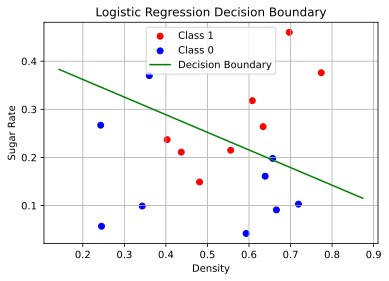

In [159]:
#不知道怎么画分割线，这是问ai得到的答案

y_np = y_tensor.numpy().ravel()  # 转换为numpy并展开为(17,)

# 绘制数据点 - 修正索引错误
plt.scatter(x[y_np==1, 0], x[y_np==1, 1], c='red', label='Class 1')  # 修正索引
plt.scatter(x[y_np==0, 0], x[y_np==0, 1], c='blue', label='Class 0')  # 修正索引

# 绘制决策边界 - 修正计算
x1 = np.linspace(x[:,0].min()-0.1, x[:,0].max()+0.1, 100)
x2 = -(w[0].item()*x1 + b.item()) / w[1].item()  # 计算边界线
plt.plot(x1, x2, 'g-', label='Decision Boundary')

plt.xlabel('Density')
plt.ylabel('Sugar Rate')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.grid(True)
plt.show()